# Exp7.2.6.1 — Sum-CE vs Mean-CE

Analysis-only notebook. It reads finalized summary CSVs only.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    path = (start or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root')

REPO_ROOT = find_repo_root()
root = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_7_2_6_1_sum_vs_mean_ce' / 'sum_vs_mean_ce_v1'
native = pd.read_csv(root / 'native_performance_summary.csv')
probes = pd.read_csv(root / 'l2_probe_summary.csv')
delta = pd.read_csv(root / 'paired_delta_summary.csv')
equiv = pd.read_csv(root / 'readout_equivalence_summary.csv')
scaling = pd.read_csv(root / 'scaling_diagnostics_summary.csv')
history = pd.read_csv(root / 'training_history_summary.csv')

## 1. Native sequence classification
Primary comparison: reused Exp7.2.6 C0 Sum-CE vs paired Mean-CE.

In [2]:
display(native[native['split'] == 'test'].sort_values('condition'))
display(delta.sort_values('metric'))

,condition,split,n,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,objective_loss_mean,objective_loss_std
0,mean_ce,test,3,0.559361,0.008543,0.545353,0.010733,0.534890,0.020428,1.456758,0.075157
3,sum_ce_reuse_c0,test,3,0.413242,0.027587,0.403920,0.020167,0.387476,0.016556,3.640081,0.167876


,metric,n,mean_minus_sum_mean,mean_minus_sum_std,sum_value_mean,sum_value_std,mean_value_mean,mean_value_std
0,l2_fixed250_linear_test_ba,3,0.120857,0.032192,0.475154,0.030050,0.596010,0.035544
1,l2_wholecount_linear_test_ba,3,0.135162,0.041433,0.422473,0.023676,0.557635,0.022399
2,l2_wholecount_matched_biasfree_test_ba,3,0.066435,0.013089,0.404869,0.034049,0.471304,0.022317
3,native_test_ba,3,0.141433,0.016997,0.403920,0.020167,0.545353,0.010733


## 2. Fixed-model readout equivalence
For bias-free output, sum and mean logits must have identical argmax predictions.

In [3]:
display(equiv.sort_values(['model_state', 'split']))

,model_state,split,n,prediction_equal_mean,prediction_equal_std,max_relation_error_mean,max_relation_error_std,sum_ba_mean,sum_ba_std,mean_ba_mean,mean_ba_std,sum_ce_mean,sum_ce_std,mean_ce_mean,mean_ce_std
0,initial_shared_weights,val,3,1.0,0.0,0.000004,0.000002,0.085275,0.020807,0.085275,0.020807,4.040109,0.646265,2.486033,0.002262
1,trained_mean_model,test,3,1.0,0.0,0.000258,0.000012,0.545353,0.010733,0.545353,0.010733,48.633349,0.907095,1.456758,0.075157
2,trained_mean_model,train,3,1.0,0.0,0.000457,0.000035,0.851709,0.073302,0.851709,0.073302,8.916245,4.065001,0.776546,0.247290
3,trained_mean_model,val,3,1.0,0.0,0.000378,0.000063,0.558728,0.038638,0.558728,0.038638,35.442097,1.479594,1.341201,0.127758
4,trained_sum_model,test,3,1.0,0.0,0.000019,0.000004,0.403920,0.020167,0.403920,0.020167,3.640081,0.167877,2.391080,0.002222
5,trained_sum_model,train,3,1.0,0.0,0.000034,0.000008,0.892791,0.012019,0.892791,0.012019,0.350362,0.037864,2.340044,0.005640
6,trained_sum_model,val,3,1.0,0.0,0.000018,0.000002,0.393296,0.012865,0.393296,0.012865,2.965902,0.459155,2.412730,0.007612


## 3. Training-scale diagnostics
Compare logit magnitude and analytical output-weight gradient norm under sum versus mean scaling.

In [4]:
display(scaling.sort_values(['model_state', 'split', 'readout_scale']))

,model_state,split,readout_scale,n,mean_logit_l2_mean,mean_logit_l2_std,std_logit_l2_mean,std_logit_l2_std,corr_length_logit_l2_mean,corr_length_logit_l2_std,mean_output_w_grad_fro_mean,mean_output_w_grad_fro_std,std_output_w_grad_fro_mean,std_output_w_grad_fro_std,corr_length_output_w_grad_fro_mean,corr_length_output_w_grad_fro_std
0,initial_shared_weights,val,mean,3,0.051380,0.013885,0.084302,0.018516,0.089113,0.050248,0.303890,0.074062,0.483741,0.092334,0.093109,0.028835
1,initial_shared_weights,val,sum,3,4.813477,1.282023,8.189201,1.906061,0.171564,0.041901,36.066727,8.657962,65.348242,13.493154,0.184022,0.025896
2,trained_mean_model,test,mean,3,8.567985,1.047866,1.841723,0.094649,0.260051,0.011730,3.424711,0.085400,1.443778,0.136313,-0.081225,0.039432
3,trained_mean_model,test,sum,3,718.408101,87.572012,257.279841,25.771757,0.809820,0.020116,223.990326,5.273976,279.414022,4.310455,0.039843,0.017402
4,trained_mean_model,train,mean,3,8.262763,1.148050,2.468530,0.120255,-0.078162,0.032138,2.226070,0.492706,0.993931,0.065103,0.113270,0.085953
5,trained_mean_model,train,sum,3,843.503153,120.089251,345.594106,38.251868,0.530851,0.052191,77.220050,39.111957,205.322362,53.882085,0.183470,0.040349
6,trained_mean_model,val,mean,3,7.755998,1.026485,2.848061,0.052800,0.167130,0.020835,2.952347,0.057465,1.354712,0.047190,0.098339,0.032773
7,trained_mean_model,val,sum,3,712.157043,94.230173,332.796153,23.083225,0.563003,0.049661,210.143992,2.083895,283.193929,10.631039,0.209218,0.024546
8,trained_sum_model,test,mean,3,0.381143,0.043956,0.241274,0.037920,0.040489,0.064849,1.273223,0.088703,0.788210,0.038476,0.079785,0.021538
9,trained_sum_model,test,sum,3,31.689276,3.465526,21.161716,2.905444,0.367879,0.052967,80.018361,4.798933,93.555143,6.850036,0.110380,0.053685


## 4. L2 representation accessibility
Check whether changing only CE normalization also changes what remains linearly accessible from L2.

In [5]:
display(probes[probes['split'] == 'test'].sort_values(['probe', 'condition']))

,condition,probe,split,n,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
0,mean_ce,l2_fixed250_linear,test,3,0.609589,0.034925,0.596010,0.035544,0.595646,0.037730
9,sum_ce_reuse_c0,l2_fixed250_linear,test,3,0.484018,0.032288,0.475154,0.030050,0.472445,0.032117
3,mean_ce,l2_wholecount_linear,test,3,0.568493,0.025628,0.557635,0.022399,0.547807,0.028555
12,sum_ce_reuse_c0,l2_wholecount_linear,test,3,0.436073,0.019640,0.422473,0.023676,0.395668,0.029891
6,mean_ce,l2_wholecount_matched_biasfree,test,3,0.474886,0.025830,0.471304,0.022317,0.470853,0.023199
15,sum_ce_reuse_c0,l2_wholecount_matched_biasfree,test,3,0.413242,0.035517,0.404869,0.034049,0.383189,0.038690


## 5. Aggregate training curves

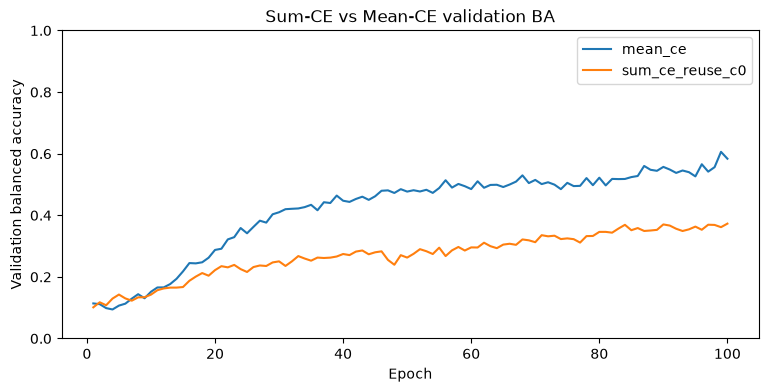

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for condition, frame in history.groupby('condition'):
    ax.plot(frame['epoch'], frame['val_ba_mean'], label=condition)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation balanced accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Sum-CE vs Mean-CE validation BA')
plt.show()